<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAINGUYENDUYVU2026/blob/main/BTAI_27042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 6.5 MB/s eta 0:00:00


Giá cước ước tính (thang 100): 92.53
Điểm thưởng tài xế (thang 100): 90.97


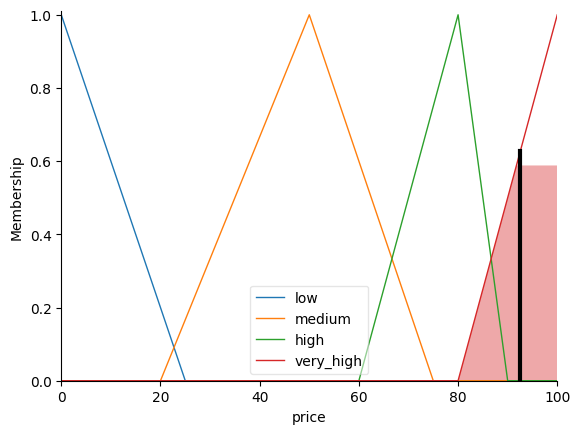

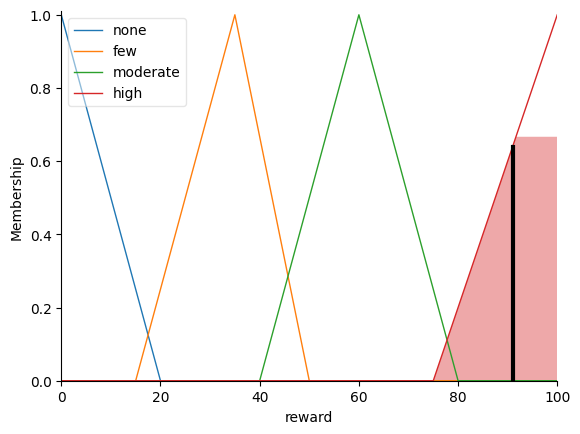

In [2]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 6, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')

distance['short'] = fuzzy.trapmf(distance.universe, [0, 0, 3, 5])
distance['medium'] = fuzzy.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzzy.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzzy.trapmf(distance.universe, [15, 32, 50, 50])

traffic['low'] = fuzzy.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzzy.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzzy.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzzy.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzzy.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzzy.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzzy.trimf(weather.universe, [0, 0, 4])
weather['moderate'] = fuzzy.trimf(weather.universe, [3, 5, 7])
weather['bad'] = fuzzy.trimf(weather.universe, [6, 10, 10])

rating['poor'] = fuzzy.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzzy.trimf(rating.universe, [2, 3.25, 4.5])
rating['good'] = fuzzy.trimf(rating.universe, [3.5, 5, 5])

punctuality['late'] = fuzzy.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzzy.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzzy.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzzy.trimf(price.universe, [0, 0, 25])
price['medium'] = fuzzy.trimf(price.universe, [20, 50, 75])
price['high'] = fuzzy.trimf(price.universe, [60, 80, 90])
price['very_high'] = fuzzy.trimf(price.universe, [80, 100, 100])

reward['none'] = fuzzy.trimf(reward.universe, [0, 0, 20])
reward['few'] = fuzzy.trimf(reward.universe, [15, 35, 50])
reward['moderate'] = fuzzy.trimf(reward.universe, [40, 60, 80])
reward['high'] = fuzzy.trimf(reward.universe, [75, 100, 100])

rules = [
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),

    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 25
grab_sim.input['traffic'] = 80
grab_sim.input['demand'] = 90
grab_sim.input['weather'] = 9
grab_sim.input['rating'] = 4.8
grab_sim.input['punctuality'] = 90

grab_sim.compute()

print(f"Giá cước ước tính (thang 100): {grab_sim.output['price']:.2f}")
print(f"Điểm thưởng tài xế (thang 100): {grab_sim.output['reward']:.2f}")

price.view(sim=grab_sim)
reward.view(sim=grab_sim)